In [2]:
from my_lib import pd , sns , plt , np

In [3]:
# df = pd.read_csv("combined_data.csv")
# df.rename(columns={"Messages" :"text" , "Category": "label" })  

In [4]:
# df["label"] = df["label"].apply(lambda x: "spam" if x == 1 else "ham")
# df.rename(columns= {"label" : "Result" , "text" : "Messages"} ,  inplace=True)

In [5]:
# df = pd.read_csv("spam_dataset1.csv")
# df


In [6]:
df= pd.read_csv("spam_dataset.csv")

In [7]:
df["Result"].value_counts()

Result
ham     54015
spam    46151
Name: count, dtype: int64

In [8]:
df.head()

,Result,Messages
0,spam,ounce feather bowl hummingbird opec moment ala...
1,spam,wulvob get your medircations online qnb ikud v...
2,ham,computer connection from cnn com wednesday es...
3,spam,university degree obtain a prosperous future m...
4,ham,thanks for all your answers guys i know i shou...


In [9]:
x = df.drop("Result" , axis = 1)
y = df["Result"]

In [10]:
y.value_counts()

Result
ham     54015
spam    46151
Name: count, dtype: int64

In [11]:
x.isna().sum()

Messages    0
dtype: int64

In [12]:
y.isna().sum()

np.int64(0)

In [13]:
df.describe()

,Result,Messages
count,100166,100166
unique,2,89801
top,ham,"Sorry, I'll call later"
freq,54015,90


In [14]:
df.head()

,Result,Messages
0,spam,ounce feather bowl hummingbird opec moment ala...
1,spam,wulvob get your medircations online qnb ikud v...
2,ham,computer connection from cnn com wednesday es...
3,spam,university degree obtain a prosperous future m...
4,ham,thanks for all your answers guys i know i shou...


# text_Preprocessing

In [15]:
import nltk

In [16]:
nltk.download("stopwords")
nltk.download("punkt")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\bhave\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\bhave\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [17]:
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer , WordNetLemmatizer
from nltk.tokenize import  word_tokenize 
import re
import contractions

In [18]:
# def Remove_Punctuations(text):
#     new_text = text
#     import string
#     for i in new_text:
#         if i in string.punctuation:
#             new_text = new_text.replace(i , "")

     
#     return new_text

In [19]:
# def Remove_digits(ls):
#     filtred_list = []
#     for i in ls:
#         if i.isalpha():
#             filtred_list.append(i)
#     return filtred_list

In [20]:
# pip install contractions

In [21]:
stop_words = set(stopwords.words('english')) - {"not", "no"}
stemmer = PorterStemmer()
lemmatize = WordNetLemmatizer()

def preprocess(text):
    new_text = text.lower()
    new_text = contractions.fix(new_text)
    new_text = new_text.translate(str.maketrans("", "", string.punctuation))
    words = word_tokenize(new_text)
    words = [word for word in words if word.isalpha()]
    words = [word for word in words if word not in stop_words]
    words = [lemmatize.lemmatize(word) for word in words]
    return " ".join(words)

In [22]:
x["Messages"] = x["Messages"].apply(preprocess)
x

,Messages
0,ounce feather bowl hummingbird opec moment ala...
1,wulvob get medircations online qnb ikud viagra...
2,computer connection cnn com wednesday escapenu...
3,university degree obtain prosperous future mon...
4,thanks answer guy know checked rsync manual wo...
...,...
100161,time tried contact pound prize claim easy call...
100162,ì b going esplanade fr home
100163,pity mood soany suggestion
100164,guy bitching acted like would interested buyin...


In [31]:
from imblearn.over_sampling import SMOTE

In [32]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split( x["Messages"], y, test_size=0.3  , stratify=y)

In [33]:
x_train

70740    hi bored tonight escapenumber girl would like ...
49365    new hurricane forecast csu renowned hurricane ...
38873    dear valued member writing inform result recen...
87263                                     not know wat get
5931     dear navroz thanks getting back reason dialogu...
                               ...                        
19603    top quality replica watch specialty wearing ex...
42100    royal b edmondson reliantenergy com ami choksh...
19257    best new dating site net check singlesnet onli...
983      site find terrific gift spring summer many sty...
41734    use data dumper module see four dimension arra...
Name: Messages, Length: 70116, dtype: object

In [34]:
y_train.value_counts()

Result
ham     37810
spam    32306
Name: count, dtype: int64

In [35]:
x_test

77180    greeting nesa hea member attached review two f...
12103    done original message symes kate sent monday j...
61587    escapenumber escapenumber escapenumber richard...
911      dear ou team itinerary interview montford inn ...
21426    see attachment http www blantoan net ennis del...
                               ...                        
67339    paul think option pretty limited mixed effect ...
33053    mon may escapenumber escapenumber escapenumber...
92047    love ya try budget money better babe gary woul...
23579    file home jelmer bzr samba old escapenumber es...
58961    hi deepayan following code creates dummy datas...
Name: Messages, Length: 30050, dtype: object

In [36]:
y_test.value_counts()

Result
ham     16205
spam    13845
Name: count, dtype: int64

In [37]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer , CountVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier , PassiveAggressiveClassifier
from sklearn.metrics import classification_report, confusion_matrix ,precision_recall_curve , accuracy_score , ConfusionMatrixDisplay 
from sklearn.model_selection import cross_val_score

In [38]:
models = {
    "MultinomialNB": MultinomialNB(),
    "BernoulliNB": BernoulliNB(),
    "LogisticRegression": LogisticRegression(max_iter=1000),
    # "SVM": SVC(probability=True),
    "DecisionTree": DecisionTreeClassifier(),
    "RandomForest": RandomForestClassifier(),
    "GradientBoosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "KNN": KNeighborsClassifier(),
    "SGD Classifier": SGDClassifier(loss='log_loss', max_iter=1000),
    "PassiveAggressiveClassifier" :PassiveAggressiveClassifier()
}
models

{'MultinomialNB': MultinomialNB(),
 'BernoulliNB': BernoulliNB(),
 'LogisticRegression': LogisticRegression(max_iter=1000),
 'DecisionTree': DecisionTreeClassifier(),
 'RandomForest': RandomForestClassifier(),
 'GradientBoosting': GradientBoostingClassifier(),
 'AdaBoost': AdaBoostClassifier(),
 'KNN': KNeighborsClassifier(),
 'SGD Classifier': SGDClassifier(loss='log_loss'),
 'PassiveAggressiveClassifier': PassiveAggressiveClassifier()}


 MODEL: MultinomialNB
 Accuracy: 91.62396006655574

Classification Report:
              precision    recall  f1-score   support

         ham       0.95      0.89      0.92     16205
        spam       0.88      0.95      0.91     13845

    accuracy                           0.92     30050
   macro avg       0.92      0.92      0.92     30050
weighted avg       0.92      0.92      0.92     30050



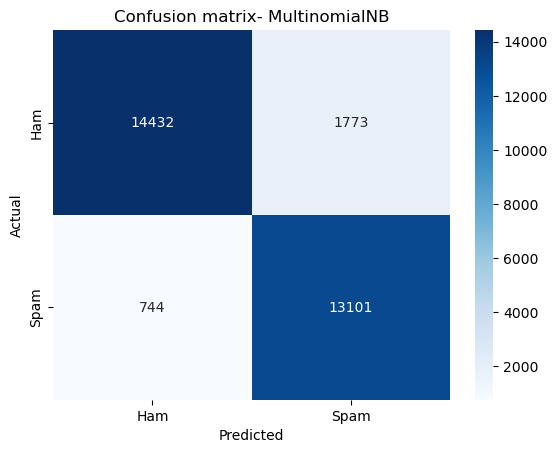

----------------------------------------------------------------------------------------------------

 MODEL: BernoulliNB
 Accuracy: 80.62229617304493

Classification Report:
              precision    recall  f1-score   support

         ham       0.97      0.66      0.79     16205
        spam       0.71      0.97      0.82     13845

    accuracy                           0.81     30050
   macro avg       0.84      0.82      0.80     30050
weighted avg       0.85      0.81      0.80     30050



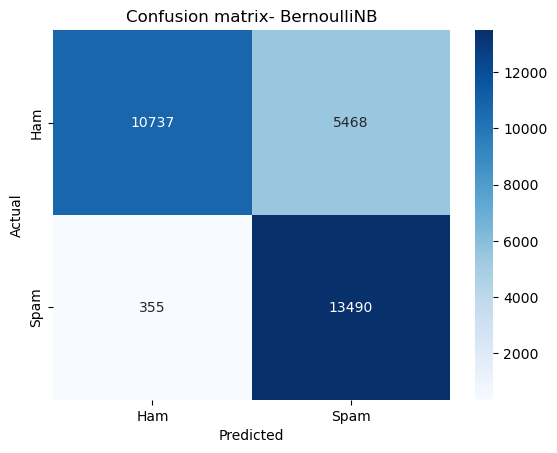

----------------------------------------------------------------------------------------------------

 MODEL: LogisticRegression
 Accuracy: 96.18968386023295

Classification Report:
              precision    recall  f1-score   support

         ham       0.96      0.97      0.96     16205
        spam       0.97      0.95      0.96     13845

    accuracy                           0.96     30050
   macro avg       0.96      0.96      0.96     30050
weighted avg       0.96      0.96      0.96     30050



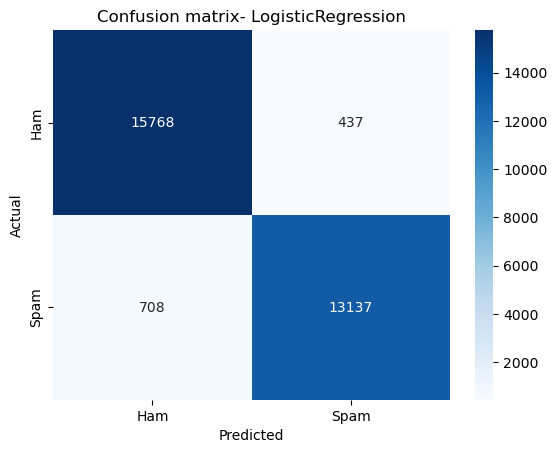

----------------------------------------------------------------------------------------------------

 MODEL: DecisionTree
 Accuracy: 95.13477537437603

Classification Report:
              precision    recall  f1-score   support

         ham       0.95      0.96      0.96     16205
        spam       0.95      0.94      0.95     13845

    accuracy                           0.95     30050
   macro avg       0.95      0.95      0.95     30050
weighted avg       0.95      0.95      0.95     30050



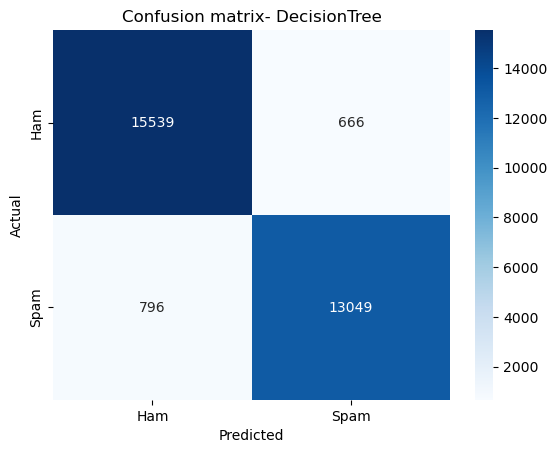

----------------------------------------------------------------------------------------------------

 MODEL: RandomForest
 Accuracy: 97.78036605657238

Classification Report:
              precision    recall  f1-score   support

         ham       0.98      0.98      0.98     16205
        spam       0.98      0.97      0.98     13845

    accuracy                           0.98     30050
   macro avg       0.98      0.98      0.98     30050
weighted avg       0.98      0.98      0.98     30050



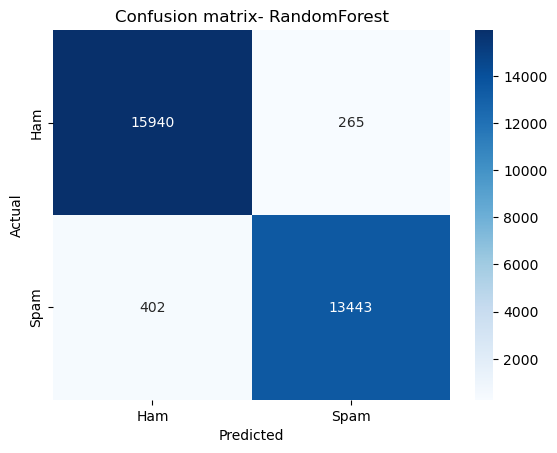

----------------------------------------------------------------------------------------------------

 MODEL: GradientBoosting
 Accuracy: 91.94009983361065

Classification Report:
              precision    recall  f1-score   support

         ham       0.90      0.96      0.93     16205
        spam       0.95      0.87      0.91     13845

    accuracy                           0.92     30050
   macro avg       0.92      0.92      0.92     30050
weighted avg       0.92      0.92      0.92     30050



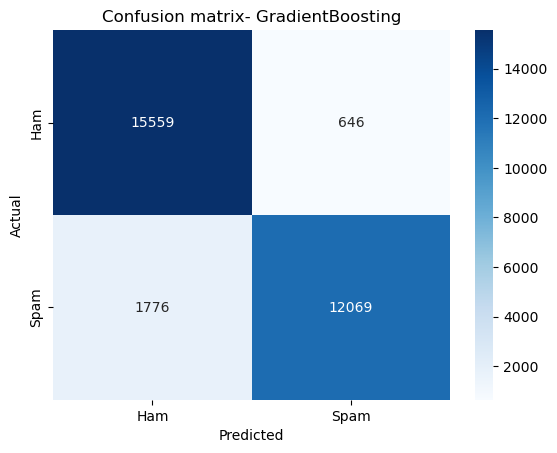

----------------------------------------------------------------------------------------------------

 MODEL: AdaBoost
 Accuracy: 85.44093178036606

Classification Report:
              precision    recall  f1-score   support

         ham       0.83      0.92      0.87     16205
        spam       0.89      0.78      0.83     13845

    accuracy                           0.85     30050
   macro avg       0.86      0.85      0.85     30050
weighted avg       0.86      0.85      0.85     30050



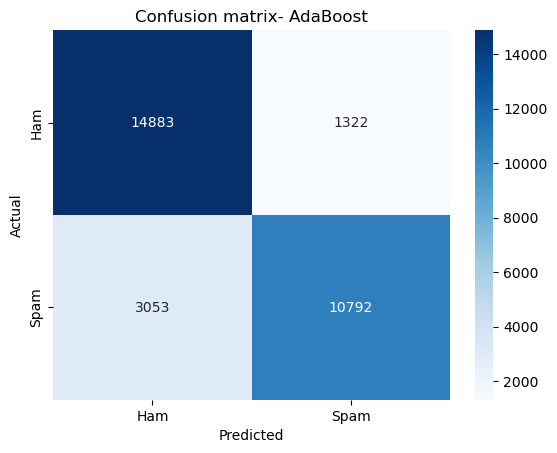

----------------------------------------------------------------------------------------------------

 MODEL: KNN
 Accuracy: 87.72379367720465

Classification Report:
              precision    recall  f1-score   support

         ham       0.85      0.93      0.89     16205
        spam       0.91      0.81      0.86     13845

    accuracy                           0.88     30050
   macro avg       0.88      0.87      0.88     30050
weighted avg       0.88      0.88      0.88     30050



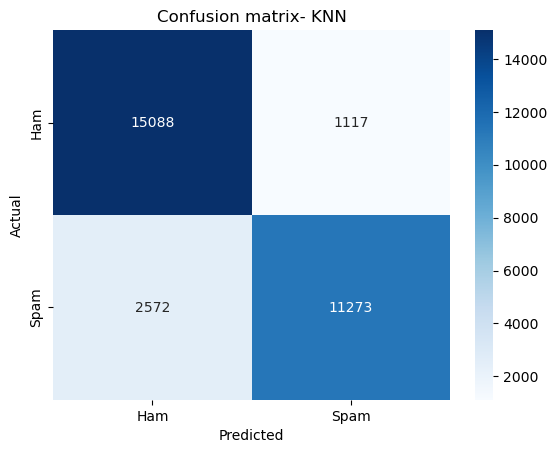

----------------------------------------------------------------------------------------------------

 MODEL: SGD Classifier
 Accuracy: 95.02163061564059

Classification Report:
              precision    recall  f1-score   support

         ham       0.94      0.97      0.95     16205
        spam       0.96      0.93      0.95     13845

    accuracy                           0.95     30050
   macro avg       0.95      0.95      0.95     30050
weighted avg       0.95      0.95      0.95     30050



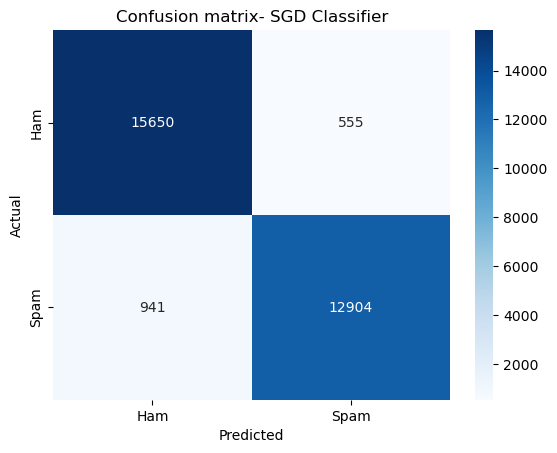

----------------------------------------------------------------------------------------------------

 MODEL: PassiveAggressiveClassifier
 Accuracy: 96.79201331114808

Classification Report:
              precision    recall  f1-score   support

         ham       0.96      0.98      0.97     16205
        spam       0.97      0.96      0.96     13845

    accuracy                           0.97     30050
   macro avg       0.97      0.97      0.97     30050
weighted avg       0.97      0.97      0.97     30050



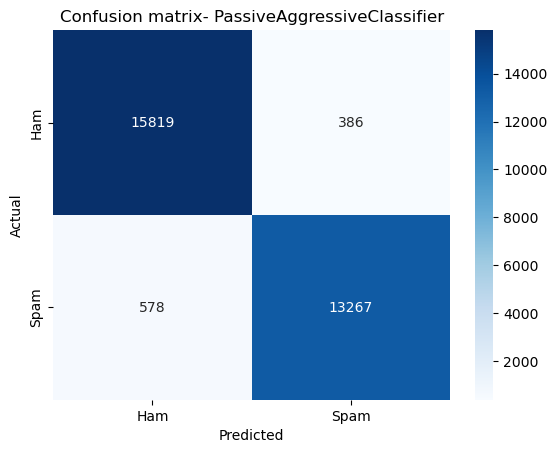

----------------------------------------------------------------------------------------------------


In [39]:
for name, model in models.items():
    pipe = Pipeline([
    ("tfidf" , TfidfVectorizer(max_features=5000 , ngram_range=(1,2))),
    ("model" , model)
    ])
    print(f"\n MODEL: {name}")
    pipe.fit(x_train, y_train)
    y_pred = pipe.predict(x_test)
    print("="*50)
    print(f" Accuracy:", accuracy_score(y_test, y_pred) * 100)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test , y_pred)
    sns.heatmap(cm  , annot = True ,fmt='d', cmap='Blues',xticklabels=["Ham", "Spam"],yticklabels=["Ham", "Spam"])
    plt.title(f"Confusion matrix- {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    print("-" * 100)

In [41]:
rf_pipe = Pipeline([
    ("tfidf" , TfidfVectorizer(max_features=5000 , ngram_range=(1,2))),
    ("model" , RandomForestClassifier())
])
rf_pipe

,steps,"[('tfidf', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [80]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split( x["Messages"], y, test_size=0.2  , stratify=y)

In [62]:
rf_pipe.fit(x_train , y_train)

,steps,"[('tfidf', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [63]:
y_pred = rf_pipe.predict(x_test)
y_pred

array(['spam', 'spam', 'spam', ..., 'ham', 'spam', 'spam'],
      shape=(20034,), dtype=object)

In [64]:
confusion_matrix(y_test , y_pred)

array([[10652,   151],
       [  255,  8976]])

In [58]:
from sklearn.model_selection import cross_validate , cross_val_score

In [60]:
cv_results = cross_validate(rf_pipe,x_train,y_train,cv=5,scoring='accuracy',return_train_score=True)
print("Train Accuracy (CV):", cv_results['train_score'].mean())
print("Validation Accuracy (CV):", cv_results['test_score'].mean())

Train Accuracy (CV): 0.9969336528673344
Validation Accuracy (CV): 0.9751982502139036


In [ ]:
test_score = rf_pipe.score(X_test, y_test)

print("Test Accuracy:", test_score)

In [66]:
cross_val_score(rf_pipe , x_train , y_train , cv =5)

array([0.97691396, 0.97504212, 0.97348059, 0.97535255, 0.97816049])

In [68]:
cross_val_score(rf_pipe , x_test , y_test , cv =5)

array([0.96580983, 0.96306464, 0.96281507, 0.96306464, 0.96230654])

In [70]:
from scipy.stats import randint

In [73]:
param_dist = {
    'model__n_estimators': randint(100, 300),
    'model__max_depth': [10, 15, 20, None],
    'model__min_samples_split': randint(2, 10),
    'model__min_samples_leaf': randint(1, 4),
    'model__max_features': ['sqrt', 'log2']
}
param_dist

{'model__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen at 0x1fba8dcf460>,
 'model__max_depth': [10, 15, 20, None],
 'model__min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen at 0x1fba8dcf020>,
 'model__min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen at 0x1fba8b9db50>,
 'model__max_features': ['sqrt', 'log2']}

In [75]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV

In [76]:
random_search = RandomizedSearchCV(
    rf_pipe,
    param_distributions=param_dist,
    n_iter=10,        # 10 combinations
    cv=3,             # 3-fold cross validation
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)
random_search

,estimator,Pipeline(step...lassifier())])
,param_distributions,"{'model__max_depth': [10, 15, ...], 'model__max_features': ['sqrt', 'log2'], 'model__min_samples_leaf': <scipy.stats....001FBA8B9DB50>, 'model__min_samples_split': <scipy.stats....001FBA8DCF020>, ...}"
,n_iter,10
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [81]:
random_search.fit(x_train , y_train)

,estimator,Pipeline(step...lassifier())])
,param_distributions,"{'model__max_depth': [10, 15, ...], 'model__max_features': ['sqrt', 'log2'], 'model__min_samples_leaf': <scipy.stats....001FBA8B9DB50>, 'model__min_samples_split': <scipy.stats....001FBA8DCF020>, ...}"
,n_iter,10
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [130]:
print("Best Parameters:\n", random_search.best_params_)
print("\nBest CV Score:", random_search.best_score_)

Best Parameters:
 {'model__max_depth': None, 'model__max_features': 'log2', 'model__min_samples_leaf': 1, 'model__min_samples_split': 4, 'model__n_estimators': 150}

Best CV Score: 0.975752503992999


In [151]:
random_search.best_estimator_

,steps,"[('tfidf', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [129]:
# -------------------------------
# 8. Test Evaluation
# -------------------------------
best_model = random_search.best_estimator_

y_pred = best_model.predict(x_test)

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Confusion Matrix:
 [[10658   145]
 [  246  8985]]

Classification Report:
               precision    recall  f1-score   support

         ham       0.98      0.99      0.98     10803
        spam       0.98      0.97      0.98      9231

    accuracy                           0.98     20034
   macro avg       0.98      0.98      0.98     20034
weighted avg       0.98      0.98      0.98     20034



In [131]:
best_model

,steps,"[('tfidf', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [140]:
import pickle

In [144]:
with open("best_model.pkl" , "wb") as file:
    pickle.dump(best_model , file)

In [147]:
with open("best_model.pkl" , "rb") as file:
    MODEL = pickle.load(file)

In [150]:
MODEL.predict(msg_spam)

array(['spam'], dtype=object)

In [134]:
best_model.predict(msg)

array(['ham'], dtype=object)

In [139]:
best_model.predict(msg_spam)

array(['spam'], dtype=object)

In [92]:
best_model.predict(msg1)

array(['spam'], dtype=object)

In [93]:
best_model.predict(["Free money offer!!!"])

array(['spam'], dtype=object)

In [95]:
best_model.predict(["Hey bro, kal milte hain"])

array(['ham'], dtype=object)

In [120]:
y_prob = best_model.predict_proba(x_test)[:,1]
y_prob

array([0.05022222, 0.18133499, 0.01022222, ..., 0.07288889, 0.00222222,
       0.80825397], shape=(20034,))

In [99]:
y_prob

array([0.05022222, 0.18133499, 0.01022222, ..., 0.07288889, 0.00222222,
       0.80825397], shape=(20034,))

In [100]:
threshold = 0.7   # try 0.6, 0.7, 0.8

In [101]:
y_pred_new = (y_prob >= threshold).astype(int)

In [102]:
y_pred_new

array([0, 0, 0, ..., 0, 0, 1], shape=(20034,))

In [107]:
Y_test = y_test.map({'ham': 0, 'spam': 1})

print(confusion_matrix(Y_test, y_pred))
print(classification_report(Y_test, y_pred))

[[10658   145]
 [  246  8985]]
              precision    recall  f1-score   support

           0       0.98      0.99      0.98     10803
           1       0.98      0.97      0.98      9231

    accuracy                           0.98     20034
   macro avg       0.98      0.98      0.98     20034
weighted avg       0.98      0.98      0.98     20034



In [125]:
y_pred = (y_prob >= 0.6)
print("Threshold:", t)
print(y_pred)
print(confusion_matrix(Y_test, y_pred))
print(classification_report(Y_test, y_pred))

Threshold: 0.8
[False False False ... False False  True]
[[10749    54]
 [  483  8748]]
              precision    recall  f1-score   support

           0       0.96      1.00      0.98     10803
           1       0.99      0.95      0.97      9231

    accuracy                           0.97     20034
   macro avg       0.98      0.97      0.97     20034
weighted avg       0.97      0.97      0.97     20034



In [117]:
for t in [0.5, 0.6, 0.7, 0.8]:
    y_pred = (y_prob >= t)
    print("Threshold:", t)
    print(y_pred)
    print(confusion_matrix(Y_test, y_pred))
    print(classification_report(Y_test, y_pred))

Threshold: 0.5
[False False False ... False False  True]
[[10658   145]
 [  246  8985]]
              precision    recall  f1-score   support

           0       0.98      0.99      0.98     10803
           1       0.98      0.97      0.98      9231

    accuracy                           0.98     20034
   macro avg       0.98      0.98      0.98     20034
weighted avg       0.98      0.98      0.98     20034

Threshold: 0.6
[False False False ... False False  True]
[[10749    54]
 [  483  8748]]
              precision    recall  f1-score   support

           0       0.96      1.00      0.98     10803
           1       0.99      0.95      0.97      9231

    accuracy                           0.97     20034
   macro avg       0.98      0.97      0.97     20034
weighted avg       0.97      0.97      0.97     20034

Threshold: 0.7
[False False False ... False False  True]
[[10776    27]
 [  950  8281]]
              precision    recall  f1-score   support

           0       0.92    

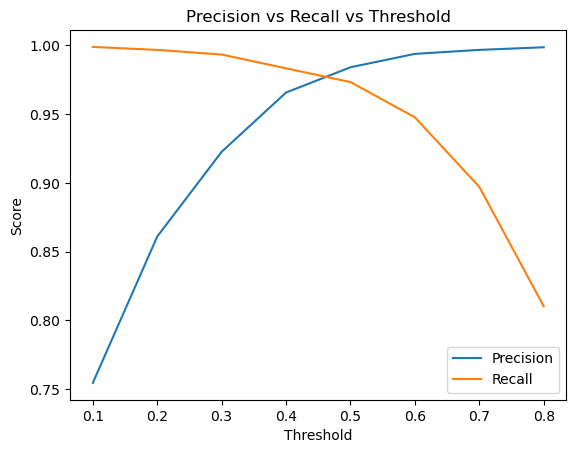

In [110]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score

thresholds = np.arange(0.1, 0.9, 0.1)

precisions = []
recalls = []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    precisions.append(precision_score(Y_test, y_pred))
    recalls.append(recall_score(Y_test, y_pred))

plt.plot(thresholds, precisions, label="Precision")
plt.plot(thresholds, recalls, label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision vs Recall vs Threshold")
plt.legend()
plt.show()

In [3]:
import pickle

In [5]:
with open("best_model.pkl" , "rb") as f:
    model = pickle.load(f)

In [6]:
model

,steps,"[('tfidf', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [196]:
class ThresholdClassifier:
    def __init__(self, model, threshold=0.6):
        self.model = model
        self.threshold = threshold

    def predict(self, X):
        probs = self.model.predict_proba(X)[:, 1]
        self.y_pred = (probs >= self.threshold).astype(int)
        return "spam" if self.y_pred == 1 else "ham"

    def predict_proba(self, X):
        return self.model.predict_proba(X)

    # def evaluations(self , y_test):
    #     # Y_test = y_test.map({'ham': 0, 'spam': 1})
    #     print(confusion_matrix(Y_test, self.y_pred))
    #     print("-"* 100)
    #     print(classification_report(Y_test, self.y_pred))


# def predict_label(text):
#     final_model = ThresholdClassifier(best_model)
#     y_pred = final_model.predict([text])[0]
#     return "spam" if y_pred == 1 else "ham"

In [197]:
predict_label("Hey there One last nudge from me One of our goals with Emergent is to democratize software building and we're proud of how far we've come A founder in the US built 20 apps One hit 300K ARR in 6 months Another founder grew to 500 users in under a month Standard Plan starts at 1 dollar Upgrade Start Building limited offer expires today unsubscribe")

'ham'

In [198]:
msg = ["""Deloitte Analyst Trainee role update Hi Sharing a role update that you may want to review Please ensure your resume details are up to date before proceeding Role Analyst Trainee Eligibility Freshers View role details If you have any questions feel free to reply to this email Thanks Eswar"""]
msg

['Deloitte Analyst Trainee role update Hi Sharing a role update that you may want to review Please ensure your resume details are up to date before proceeding Role Analyst Trainee Eligibility Freshers View role details If you have any questions feel free to reply to this email Thanks Eswar']

In [199]:
s[0] = 0
s

array([0])

In [200]:
"spam" if s == 1 else "ham"

'ham'

In [202]:
RF.predict(msg_spam)

'spam'

In [192]:
RF = ThresholdClassifier(best_model)

In [178]:
RF = ThresholdClassifier(best_model)                                                       
s = RF.predict(["""naukri.com                                              
Get app				                                          
Activate your profile and become visible to recruiters!            
	                                                              
Keyskills missing  
Your keyskills are required to activate your account  
Add                                                                             
Add missing details
Here is what you are missing on by not activating your profi le!
	You will not be able to apply to jobs                   
	You will not be contacted by recruiters                     
	You will miss out on the unique benefits offered by Naukri     
Add missing details     
	
Did you know?                                                                    
70% recruiters prefer to search candidates on Naukri instead of posting jobs       

Add missing details                                            
Applies are a click away on the naukri app                     
Available on		Google Play	App Store                      
Get App                                                   
                                                                
Scan to download                                                
Facebook		Twitter		Instagram                          
Unsubscribe	|	Report a problem                           
You have received this mail because your e-mail ID is registered with Naukri.com. This is a system-generated e-mail, please don't reply to this message.   
Please do not pay any money to anyone who promises to find you a job. IEIL shall not have any responsibility in this regard. We recommend that you visit our Terms & Conditions and the Security Advice for more information."""]  )

In [86]:
msg = ["""Deloitte Analyst Trainee role update Hi Sharing a role update that you may want to review Please ensure your resume details are up to date before proceeding Role Analyst Trainee Eligibility Freshers View role details If you have any questions feel free to reply to this email Thanks Eswar"""]
msg

['Deloitte Analyst Trainee role update Hi Sharing a role update that you may want to review Please ensure your resume details are up to date before proceeding Role Analyst Trainee Eligibility Freshers View role details If you have any questions feel free to reply to this email Thanks Eswar']

In [127]:
msg1= ["""naukri.com
Get app				
Activate your profile and become visible to recruiters!
	
Keyskills missing
Your keyskills are required to activate your account
Add
Add missing details
Here is what you are missing on by not activating your profile!
	You will not be able to apply to jobs
	You will not be contacted by recruiters
	You will miss out on the unique benefits offered by Naukri
Add missing details
	
Did you know?
70% recruiters prefer to search candidates on Naukri instead of posting jobs

Add missing details 
Applies are a click away on the naukri app
Available on		Google Play	App Store
Get App

Scan to download
Facebook		Twitter		Instagram
Unsubscribe	|	Report a problem
You have received this mail because your e-mail ID is registered with Naukri.com. This is a system-generated e-mail, please don't reply to this message.
Please do not pay any money to anyone who promises to find you a job. IEIL shall not have any responsibility in this regard. We recommend that you visit our Terms & Conditions and the Security Advice for more information."""]

In [206]:
class ThresholdClassifier:
    def __init__(self, model, threshold=0.6):
        self.model = model
        self.threshold = threshold

    def predict(self, text):
        prob = self.model.predict_proba(text)[0][1] 
        
        return "spam" if prob >= self.threshold else "ham"

In [207]:
sv = ThresholdClassifier(best_model)

In [208]:
sv.predict(msg)

'ham'

In [214]:
best_model.predict_proba(msg)[:,1]

array([0.32526068])